<a href="https://colab.research.google.com/github/acastellanos-ie/NLP-MBDS-EN/blob/main/06_transfer_learning_and_fine_tuning/practice_solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transfer Learning for Text Classification

In this practice we will address a text classification problem: we will try to predict whether a given tweet is about a real disaster or not. In particular I propose you the scenario presented at the [Real or Not? NLP with Disaster Tweets Kaggle Competition.](https://www.kaggle.com/c/nlp-getting-started/leaderboard).

To that, I am going to follow 2 different approaches:
- Apply traditional text classification methodologies based on "simple" Machine Learning models
- Apply state-of-the-art deep learning models


We will use this practice to also put in practice the concept of **Transfer Learning**. If you are training a huge model from scratch, you do need a lot of data and GPU time. Lucklily for us, these huge models are already pre-trained for many languages using large datasets (e.g. Wikipedia). All we have to do is to adapt these models to our particular domain. 65K documents are not enough to learn English, but they are definitely enough to learn the nuances of the dataset.

Cool, now we have a model adapted to the specific language in my dataset but the business case was to create a classifier. Why am I even doing all of this? In the traditional ML methodologies we were feeding our algorithms with a rather simple representation of our textual contents (The TF-IDF vectors). Now, thanks to the fine-tune pre-trained models, I can feed my classifier with a much more detailed and accurate representation of the input textual content. Therefore, it should be easier to the classifier to better categorize the textual content.



In [1]:
# @title Setup
%pip install -q "pandas==2.2.2" "scikit-learn==1.7.1" "matplotlib==3.10.5" "seaborn==0.13.2" "transformers==4.55.4" "sentencepiece==0.2.0" "openai>=1.66.0,<3.0.0"

from pathlib import Path

repo_path = Path("/content/NLP-MBDS-EN")
if Path("/content").exists() and not repo_path.exists():
    !git clone -q https://github.com/acastellanos-ie/NLP-MBDS-EN.git /content/NLP-MBDS-EN

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 32.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 48.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 97.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 106.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 124.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the followi

# Stage 1: Data and preprocessing

## Load the data

The labelled file has 7,613 tweets. The separate Kaggle test file has no target, so it cannot tell us how well a model works. We will create one validation set from the labelled data and leave it untouched during training.

In [2]:
from pathlib import Path
import random

import numpy as np
import pandas as pd
from IPython.display import display

candidate_data_dirs = [
    Path("nlp_disaster/data"),
    Path("06_transfer_learning_and_fine_tuning/nlp_disaster/data"),
    Path("/content/NLP-MBDS-EN/06_transfer_learning_and_fine_tuning/nlp_disaster/data"),
]
data_dir = next(
    (path for path in candidate_data_dirs if (path / "train.csv").exists()),
    None,
)
if data_dir is None:
    raise FileNotFoundError("Could not find train.csv. Run the setup cell first.")

training_df = pd.read_csv(data_dir / "train.csv")
test_df = pd.read_csv(data_dir / "test.csv")

print(f"Labelled rows: {len(training_df):,}")
print(f"Unlabelled test rows: {len(test_df):,}")
display(training_df[["text", "target"]].head(4))

Labelled rows: 7,613
Unlabelled test rows: 3,263


,text,target
0,Our Deeds are the Reason of this #earthquake M...,1
1,Forest fire near La Ronge Sask. Canada,1
2,All residents asked to 'shelter in place' are ...,1
3,"13,000 people receive #wildfires evacuation or...",1


The first four rows are all disasters because the file is ordered; they are not a representative sample. This is one reason to shuffle when we create the split. The unlabelled test set is useful for a final Kaggle submission, but using it here would produce predictions without an evaluation.

## Check the labels and repeated text

Before modelling, let’s check class balance, missing values and duplicate text.

In [3]:
class_summary = (
    training_df["target"]
    .value_counts()
    .sort_index()
    .rename(index={0: "not disaster", 1: "disaster"})
    .to_frame("rows")
)
class_summary["share"] = class_summary["rows"] / len(training_df)

duplicate_after_first = training_df.duplicated("text").sum()
repeated_mask = training_df.duplicated("text", keep=False)
conflicting_texts = training_df.groupby("text")["target"].nunique().gt(1).sum()

display(class_summary.style.format({"share": "{:.1%}"}))
print(f"Duplicate rows after the first occurrence: {duplicate_after_first}")
print(f"Rows belonging to any repeated-text group: {repeated_mask.sum()}")
print(f"Repeated texts with conflicting labels: {conflicting_texts}")
print("Missing values:")
display(training_df.isna().sum().to_frame("missing"))

,rows,share
target,,
not disaster,4342,57.0%
disaster,3271,43.0%


Duplicate rows after the first occurrence: 110
Rows belonging to any repeated-text group: 179
Repeated texts with conflicting labels: 18
Missing values:


,missing
id,0
keyword,61
location,2533
text,0
target,0


The classes are mildly imbalanced: 57% non-disaster and 43% disaster. More importantly, 179 rows belong to repeated-text groups, and 18 repeated texts have contradictory labels. A random row split could place the same text in training and validation or ask the model to learn two labels for it.

We will remove every repeated-text group. This is conservative: we lose 179 rows, but the validation result is easier to interpret. Missing keyword and location values do not matter because both models below use only the tweet text.

## One split for both models

In [4]:
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

model_df = training_df.loc[~repeated_mask, ["text", "target"]].reset_index(drop=True)
train_df, validation_df = train_test_split(
    model_df,
    test_size=0.20,
    stratify=model_df["target"],
    random_state=SEED,
)

split_summary = pd.DataFrame(
    {
        "rows": [len(train_df), len(validation_df)],
        "disaster_share": [train_df.target.mean(), validation_df.target.mean()],
    },
    index=["train", "validation"],
)
display(split_summary.style.format({"disaster_share": "{:.1%}"}))

,rows,disaster_share
train,5947,42.4%
validation,1487,42.4%


After removing repeated text, 7,434 rows remain: 5,947 for training and 1,487 for validation. Stratification keeps the disaster share at about 42% in both sets. Every result below is measured on these same 1,487 tweets.

# Stage 2: Supervised lexical baseline

Having cleaned the dataset, we now establish a performance baseline using Bag-of-Words representations and traditional ML classifiers. This step is crucial to define the "performance ceiling" of statistical methods before moving toward Deep Learning.

**Feature Engineering: TF-IDF Vectorization**

We transform the raw text into numerical feature vectors using TF-IDF (Term Frequency-Inverse Document Frequency). Unlike simple word counts, TF-IDF penalizes common stop words and rewards rare, meaningful terms, providing a weighted numerical representation of the documents in a high-dimensional Vector Space Model.

**Traditional Classifiers for Benchmarking**

We evaluate three distinct mathematical approaches to identify the most robust baseline:

- Multinomial Naïve Bayes: A probabilistic model that relies on Bayes' Theorem. It assumes conditional independence between words, which is computationally efficient and surprisingly effective for the short, keyword-heavy nature of Twitter data.
- Support Vector Machines (SVM): A discriminative model that seeks to maximize the margin between classes in high-dimensional space. SVMs are historically the gold standard for text classification due to their ability to handle large feature sets.
- Logistic Regression: A model that estimates class probabilities without the strict independence assumptions of Naïve Bayes. It is particularly effective at capturing subtle feature interactions.

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score

vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    max_features=20_000,
    sublinear_tf=True,
)
x_train = vectorizer.fit_transform(train_df["text"])
x_validation = vectorizer.transform(validation_df["text"])

classical_models = {
    "Multinomial Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(random_state=SEED),
    "Logistic regression": LogisticRegression(
        max_iter=1_000, random_state=SEED
    ),
}
classical_rows = []
for name, candidate_model in classical_models.items():
    candidate_model.fit(x_train, train_df["target"])
    candidate_prediction = candidate_model.predict(x_validation)
    classical_rows.append(
        {
            "model": name,
            "accuracy": accuracy_score(
                validation_df["target"], candidate_prediction
            ),
            "disaster_f1": f1_score(
                validation_df["target"], candidate_prediction
            ),
        }
    )

classical_comparison = pd.DataFrame(classical_rows).set_index("model")
display(classical_comparison.round(3))

baseline_model = classical_models["Logistic regression"]

baseline_probability = baseline_model.predict_proba(x_validation)[:, 1]
baseline_prediction = (baseline_probability >= 0.5).astype(int)
baseline_metrics = {
    "accuracy": accuracy_score(validation_df["target"], baseline_prediction),
    "disaster_f1": f1_score(validation_df["target"], baseline_prediction),
}
baseline_metrics;

,accuracy,disaster_f1
model,,
Multinomial Naive Bayes,0.795,0.714
Linear SVM,0.790,0.740
Logistic regression,0.807,0.750


Naive Bayes reaches about 0.795 accuracy and 0.714 disaster F1. The linear SVM raises F1 to about 0.740, and logistic regression performs best on both reported metrics at roughly 0.807 accuracy and 0.750 F1. We keep logistic regression as the lexical baseline for the later error analysis.

Accuracy is higher than disaster F1 because the majority class is non-disaster. The F1 score is the more revealing number here because it combines missed disasters and false alarms. The transformer should be compared with this strongest classical candidate, not with a deliberately weak baseline.

# Stage 3: Fine-tune a pretrained transformer

Here I want to go a step beyond to apply the most advanced methodologies in the NLP state-of-the-art: Transformers. We have already discussed Transformers in class, as well as their advantages over other methodologies.

To that end, we will use HuggingFace. HuggingFace provide under the [`transformers`](https://github.com/huggingface/transformers) library a large number of pre-trained state-of-the-art pretrained NLP models together with some handy functions to load them, fine-tune them and put them into practice.


We will use **[google/bert_uncased_L-2_H-128_A-2](https://huggingface.co/google/bert_uncased_L-2_H-128_A-2)**, a compressed version of Google’s BERT: two transformer layers, two attention heads and a hidden size of 128. It is small enough to train during the session.

## Why not use a stronger BERT?

This smaller version of BERT is not the model we would choose to maximise the score. It is the model that lets us fine-tune every parameter for three epochs during class, inspect the complete process and rerun it if something goes wrong. It has about 4.4 million parameters; **[DistilBERT base](https://huggingface.co/distilbert/distilbert-base-uncased)** has about 66 million and much more capacity, but also needs substantially more memory and computation.

The code uses Hugging Face Auto classes, so the upgrade path is deliberately visible below. Change `model_choice` to `"stronger"`, rerun from this point and expect a slower run.

In [6]:
import torch
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoModelForSequenceClassification, AutoTokenizer

torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

model_choices = {
    "live": "google/bert_uncased_L-2_H-128_A-2",
    "stronger": "distilbert/distilbert-base-uncased",
}
model_choice = "stronger"
model_id = model_choices[model_choice]
tokenizer = AutoTokenizer.from_pretrained(model_id)
token_lengths = np.array(
    tokenizer(
        model_df["text"].tolist(),
        add_special_tokens=True,
        truncation=False,
        return_length=True,
    )["length"]
)

print(f"Median tokens: {np.median(token_lengths):.0f}")
print(f"95th percentile: {np.quantile(token_lengths, 0.95):.0f}")
print(f"Longest tweet: {token_lengths.max()} tokens")
print(f"Tweets longer than 64 tokens: {(token_lengths > 64).sum()} ({(token_lengths > 64).mean():.2%})")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Median tokens: 33
95th percentile: 53
Longest tweet: 84 tokens
Tweets longer than 64 tokens: 34 (0.46%)


Tokenization turns every tweet into token IDs plus an attention mask.

Computers cannot "read" words. Tokenization breaks down sentences into smaller units (tokens) and map them to unique integers. We must use the specific tokenizer that was used when that model was originally trained. We also apply padding (to make all tweets the same length) and truncation (to cut off tweets that are too long) so the data can be processed in parallel batches.

In [7]:
MAX_LENGTH = 64

def encode_texts(texts):
    encoded = tokenizer(
        texts.tolist(),
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt",
    )
    return encoded["input_ids"], encoded["attention_mask"]

train_ids, train_mask = encode_texts(train_df["text"])
validation_ids, validation_mask = encode_texts(validation_df["text"])
train_labels = torch.tensor(train_df["target"].to_numpy(), dtype=torch.long)
validation_labels = torch.tensor(validation_df["target"].to_numpy(), dtype=torch.long)

shuffle_generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(
    TensorDataset(train_ids, train_mask, train_labels),
    batch_size=64,
    shuffle=True,
    generator=shuffle_generator,
)
validation_loader = DataLoader(
    TensorDataset(validation_ids, validation_mask, validation_labels),
    batch_size=128,
)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(validation_loader)}")

Training batches: 93
Validation batches: 12


In [8]:
from transformers import get_linear_schedule_with_warmup

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transformer_model = AutoModelForSequenceClassification.from_pretrained(
    model_id,
    num_labels=2,
).to(device)

trainable_parameters = sum(
    parameter.numel()
    for parameter in transformer_model.parameters()
    if parameter.requires_grad
)
total_parameters = sum(parameter.numel() for parameter in transformer_model.parameters())

EPOCHS = 3
optimizer = torch.optim.AdamW(transformer_model.parameters(), lr=5e-5)
training_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.10 * training_steps),
    num_training_steps=training_steps,
)

print(f"Device: {device}")
print(f"Trainable parameters: {trainable_parameters:,} / {total_parameters:,}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert/distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Device: cuda
Trainable parameters: 66,955,010 / 66,955,010


The warning about newly initialized classifier weights is expected. Pretraining supplies the encoder, not a disaster classifier. All model parameters are trainable here, so this is fine-tuning rather than using BERT as a frozen feature extractor.

<div style="border: 2px solid currentColor; border-radius: 12px; padding: 28px 24px; margin: 18px 0; text-align: center;">
  <div style="font-size: 0.85em; letter-spacing: 0.08em; text-transform: uppercase; margin-bottom: 10px;">Make a prediction</div>
  <div style="font-size: 1.5em; line-height: 1.35;"><strong>Must a pretrained BERT beat TF-IDF on this dataset after three epochs?</strong></div>
</div>

In [9]:
def evaluate_transformer(data_loader):
    transformer_model.eval()
    probabilities = []
    labels = []
    with torch.inference_mode():
        for input_ids, attention_mask, batch_labels in data_loader:
            logits = transformer_model(
                input_ids=input_ids.to(device),
                attention_mask=attention_mask.to(device),
            ).logits
            probabilities.extend(torch.softmax(logits, dim=-1)[:, 1].cpu().tolist())
            labels.extend(batch_labels.tolist())

    probabilities = np.array(probabilities)
    labels = np.array(labels)
    predictions = (probabilities >= 0.5).astype(int)
    return probabilities, predictions, labels


history = []
for epoch in range(EPOCHS):
    transformer_model.train()
    total_loss = 0.0
    for input_ids, attention_mask, batch_labels in train_loader:
        optimizer.zero_grad(set_to_none=True)
        output = transformer_model(
            input_ids=input_ids.to(device),
            attention_mask=attention_mask.to(device),
            labels=batch_labels.to(device),
        )
        output.loss.backward()
        torch.nn.utils.clip_grad_norm_(transformer_model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += output.loss.item()

    transformer_probability, transformer_prediction, true_labels = evaluate_transformer(validation_loader)
    history.append(
        {
            "epoch": epoch + 1,
            "training_loss": total_loss / len(train_loader),
            "validation_accuracy": accuracy_score(true_labels, transformer_prediction),
            "validation_disaster_f1": f1_score(true_labels, transformer_prediction),
        }
    )

history_df = pd.DataFrame(history).set_index("epoch")
display(history_df.round(3))

,training_loss,validation_accuracy,validation_disaster_f1
epoch,,,
1,0.472,0.817,0.776
2,0.320,0.825,0.767
3,0.234,0.824,0.785


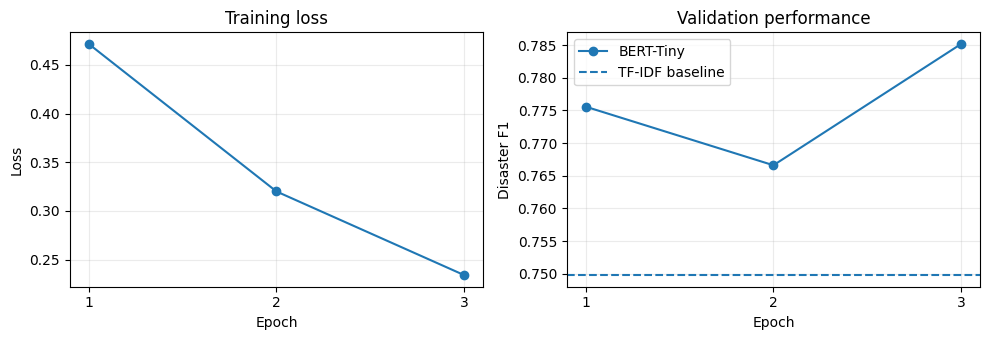

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(history_df.index, history_df["training_loss"], marker="o")
axes[0].set(title="Training loss", xlabel="Epoch", ylabel="Loss")

axes[1].plot(
    history_df.index,
    history_df["validation_disaster_f1"],
    marker="o",
    label="BERT-Tiny",
)
axes[1].axhline(
    baseline_metrics["disaster_f1"],
    linestyle="--",
    label="TF-IDF baseline",
)
axes[1].set(title="Validation performance", xlabel="Epoch", ylabel="Disaster F1")
axes[1].legend()

for axis in axes:
    axis.set_xticks(history_df.index)
    axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()

The table and curves tell the same story. Loss falls in every epoch and validation F1 rises from about 0.67 to 0.72, so the model is learning the task rather than leaving the pretrained encoder unchanged. The dashed line also makes the comparison harder to miss: the third epoch is still below the TF-IDF baseline’s 0.75 disaster F1.

That result is useful: transfer learning changes the starting point, but it does not guarantee a win. Model size, training budget, hyperparameters and the lexical nature of this dataset all matter.

# Stage 4: Evaluate and inspect

## Compare the same metrics on the same rows

In [11]:
transformer_metrics = {
    "accuracy": accuracy_score(true_labels, transformer_prediction),
    "disaster_f1": f1_score(true_labels, transformer_prediction),
}
comparison = pd.DataFrame(
    [baseline_metrics, transformer_metrics],
    index=["TF-IDF + logistic regression", "Fine-tuned Google BERT-Tiny"],
)
display(comparison.round(3))

,accuracy,disaster_f1
TF-IDF + logistic regression,0.807,0.750
Fine-tuned Google BERT-Tiny,0.824,0.785


On this split, TF-IDF leads by roughly four accuracy points and three F1 points. Google BERT-Tiny is deliberately very small, and three epochs are chosen for classroom runtime rather than an exhaustive search. The conclusion is not that transformers are worse; it is that the comparison must include data, model capacity and compute budget.

## Where do the errors go?

A confusion matrix separates false alarms from missed disasters.

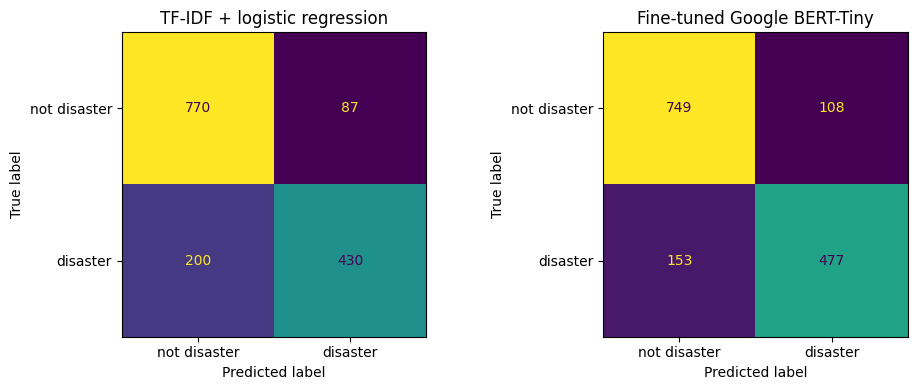

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for axis, name, prediction in [
    (axes[0], "TF-IDF + logistic regression", baseline_prediction),
    (axes[1], "Fine-tuned Google BERT-Tiny", transformer_prediction),
]:
    ConfusionMatrixDisplay(
        confusion_matrix(validation_df["target"], prediction),
        display_labels=["not disaster", "disaster"],
    ).plot(ax=axis, colorbar=False, values_format="d")
    axis.set_title(name)
plt.tight_layout()
plt.show()

The baseline misses 200 disasters and raises 87 false alarms. Google BERT-Tiny misses slightly fewer disasters, 190, but raises 153 false alarms. Its disaster recall is therefore a little better, while its precision is worse. A single F1 score compresses that trade-off.

## The most confident mistakes

In [13]:
validation_results = validation_df[["text", "target"]].reset_index(drop=True).copy()
validation_results["tfidf_probability"] = baseline_probability
validation_results["tfidf_prediction"] = baseline_prediction
validation_results["bert_probability"] = transformer_probability
validation_results["bert_prediction"] = transformer_prediction

for model_name, probability_column, prediction_column in [
    ("TF-IDF", "tfidf_probability", "tfidf_prediction"),
    ("Google BERT-Tiny", "bert_probability", "bert_prediction"),
]:
    mistakes = validation_results[
        validation_results[prediction_column] != validation_results["target"]
    ].copy()
    mistakes["confidence_in_wrong_label"] = np.where(
        mistakes[prediction_column].eq(1),
        mistakes[probability_column],
        1 - mistakes[probability_column],
    )
    print(f"\n{model_name}: most confident wrong predictions")
    display(
        mistakes.nlargest(4, "confidence_in_wrong_label")[
            ["text", "target", prediction_column, probability_column]
        ].style.format({probability_column: "{:.3f}"})
    )


TF-IDF: most confident wrong predictions


,text,target,tfidf_prediction,tfidf_probability
568,My back is so sunburned :(,1,0,0.070
142,2Leezy its like you're about to fall down a cliff but you're grabbing my hand but my palms are sweaty ... Why bruh? https://t.co/GrWdr4kuf3,1,0,0.081
112,If you're in search of powerful content to improve your business or have been frustrated with the deluge of 'quantitÛ_https://t.co/64cyMG1lTG,1,0,0.088
1423,Just came back from camping and returned with a new song which gets recorded tomorrow. Can't wait! #Desolation #TheConspiracyTheory #NewEP,1,0,0.110



Google BERT-Tiny: most confident wrong predictions


,text,target,bert_prediction,bert_probability
730,DISASTER AVERTED: Police kill gunman with Û÷hoax deviceÛª atåÊcinema http://t.co/5NG0FzpVdS,0,1,0.993
524,Kosciusko police investigating pedestrian fatality hit by a train Thursday http://t.co/m5djLLxoZP,0,1,0.992
139,Teen Disaster Preparedness Event in Van Nuys August 11 @ 5:30pm http://t.co/fXUX987vZx via @VanNuysCouncil,0,1,0.991
872,http://t.co/Gxgm1T3W0J From Devastation to Elation Getting Back on My Feet Helping Those Willing To Help Themselves http://t.co/puMxLVLsgM,0,1,0.991


Several high-confidence errors are not obviously model failures. Some tweets describe fictional crashes, quote headlines without context or use labels that are hard to infer from the text alone. Error analysis therefore checks the dataset as well as the model.

The probabilities are ranking scores, not guarantees. A prediction near 0.95 can still be wrong, especially when the annotation rule is ambiguous.

## Five controlled stress cases

These examples are not another test set. They isolate literal disaster language, metaphor, negation, ambiguity and noisy formatting.

In [14]:
stress_cases = pd.DataFrame(
    {
        "case": ["literal", "figurative", "negated", "ambiguous", "noisy"],
        "text": [
            "A wildfire destroyed twelve homes and forced residents to evacuate.",
            "My inbox is on fire after coming back from holiday.",
            "Officials confirmed that the reported explosion did not happen.",
            "What a disaster.",
            "BREAKING!!! FLOOD WARNING http://t.co/example",
        ],
    }
)
stress_cases["tfidf_disaster_probability"] = baseline_model.predict_proba(
    vectorizer.transform(stress_cases["text"])
)[:, 1]

stress_ids, stress_mask = encode_texts(stress_cases["text"])
stress_loader = DataLoader(
    TensorDataset(
        stress_ids,
        stress_mask,
        torch.zeros(len(stress_cases), dtype=torch.long),
    ),
    batch_size=len(stress_cases),
)
stress_cases["bert_disaster_probability"] = evaluate_transformer(stress_loader)[0]
display(
    stress_cases.style.format(
        {
            "tfidf_disaster_probability": "{:.3f}",
            "bert_disaster_probability": "{:.3f}",
        }
    )
)

,case,text,tfidf_disaster_probability,bert_disaster_probability
0,literal,A wildfire destroyed twelve homes and forced residents to evacuate.,0.731,0.992
1,figurative,My inbox is on fire after coming back from holiday.,0.546,0.265
2,negated,Officials confirmed that the reported explosion did not happen.,0.631,0.989
3,ambiguous,What a disaster.,0.599,0.191
4,noisy,BREAKING!!! FLOOD WARNING http://t.co/example,0.708,0.989


Both models score the literal wildfire as a disaster. Google BERT-Tiny handles the figurative “inbox is on fire” better, reducing the disaster probability from about 0.55 to 0.25. Neither model handles the negation: “explosion” remains stronger than “did not happen.”

The last row exposes a different weakness. TF-IDF recognises the lexical cues “flood warning,” while this fine-tuned Google BERT-Tiny gives the noisy uppercase tweet a low score. Contextual models do not automatically dominate lexical models on every kind of input.

# Stage 5: Zero-shot classification

The first two models learned from the disaster-tweet labels. Now we remove that supervision completely.

We will use **[google/flan-t5-small](https://huggingface.co/google/flan-t5-small)**, an instruction-tuned model published by Google. It has seen many tasks during instruction tuning, but it will not see any labelled example from this dataset. Zero-shot here means zero disaster-tweet training examples, not a model with zero previous training.

In [15]:
zero_shot_df, _ = train_test_split(
    validation_results,
    train_size=200,
    stratify=validation_results["target"],
    random_state=SEED,
)
zero_shot_df = zero_shot_df.reset_index(drop=True)

print(f"Zero-shot evaluation rows: {len(zero_shot_df)}")
print(f"Disaster share: {zero_shot_df['target'].mean():.1%}")

Zero-shot evaluation rows: 200
Disaster share: 42.5%


FLAN-T5 is slower than the two classifiers because it is a sequence-to-sequence model. We use a fixed stratified sample of 200 validation tweets to keep this stage short. The table below will recompute all three models on those same 200 rows; comparing the zero-shot sample with the full 1,487-row metrics would not be fair.

In [16]:
import torch.nn.functional as functional
from transformers import AutoModelForSeq2SeqLM

zero_shot_model_id = "google/flan-t5-small"
zero_shot_tokenizer = AutoTokenizer.from_pretrained(zero_shot_model_id)
zero_shot_model = AutoModelForSeq2SeqLM.from_pretrained(
    zero_shot_model_id
).to(device)
zero_shot_model.eval()

print(f"Model: {zero_shot_model_id}")
print(f"Parameters: {sum(p.numel() for p in zero_shot_model.parameters()):,}")

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Model: google/flan-t5-small
Parameters: 76,961,152


Free generation could return variants such as “real disaster,” “yes” or an explanation. That would mix classification quality with output-format failures. Instead, we score two fixed candidate labels, 0 and 1, under the model and normalise their likelihoods.

The numeric labels have the same token length. This avoids giving “disaster” an accidental advantage over the two-token phrase “not disaster.”

In [17]:
zero_shot_labels = ["0", "1"]

def zero_shot_prompt(tweet):
    return (
        "Classify the tweet. Use label 1 if it reports a real disaster "
        "and label 0 if it does not. Answer with only 0 or 1.\n"
        f"Tweet: {tweet}\nLabel:"
    )


def score_zero_shot_labels(texts, batch_size=32):
    disaster_probabilities = []

    for start in range(0, len(texts), batch_size):
        batch_texts = texts[start : start + batch_size]
        prompts = [zero_shot_prompt(text) for text in batch_texts]
        repeated_prompts = [
            prompt
            for prompt in prompts
            for _ in zero_shot_labels
        ]
        candidate_targets = zero_shot_labels * len(prompts)

        inputs = zero_shot_tokenizer(
            repeated_prompts,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt",
        ).to(device)
        target_ids = zero_shot_tokenizer(
            text_target=candidate_targets,
            padding=True,
            return_tensors="pt",
        )["input_ids"].to(device)
        labels = target_ids.clone()
        labels[labels == zero_shot_tokenizer.pad_token_id] = -100

        with torch.inference_mode():
            logits = zero_shot_model(**inputs, labels=labels).logits

        token_losses = functional.cross_entropy(
            logits.reshape(-1, logits.shape[-1]),
            labels.reshape(-1),
            reduction="none",
            ignore_index=-100,
        ).reshape(labels.shape)
        valid_tokens = labels.ne(-100)
        sequence_losses = (
            (token_losses * valid_tokens).sum(dim=1)
            / valid_tokens.sum(dim=1)
        )
        label_scores = (-sequence_losses).reshape(
            len(prompts), len(zero_shot_labels)
        )
        disaster_probabilities.extend(
            torch.softmax(label_scores, dim=1)[:, 1].cpu().tolist()
        )

    return np.array(disaster_probabilities)

In [18]:
zero_shot_probability = score_zero_shot_labels(
    zero_shot_df["text"].tolist()
)
zero_shot_prediction = (zero_shot_probability >= 0.5).astype(int)

sample_comparison = pd.DataFrame(
    {
        "accuracy": [
            accuracy_score(zero_shot_df["target"], zero_shot_df["tfidf_prediction"]),
            accuracy_score(zero_shot_df["target"], zero_shot_df["bert_prediction"]),
            accuracy_score(zero_shot_df["target"], zero_shot_prediction),
        ],
        "disaster_f1": [
            f1_score(zero_shot_df["target"], zero_shot_df["tfidf_prediction"]),
            f1_score(zero_shot_df["target"], zero_shot_df["bert_prediction"]),
            f1_score(zero_shot_df["target"], zero_shot_prediction),
        ],
    },
    index=[
        "TF-IDF + logistic regression",
        "Fine-tuned Google BERT-Tiny",
        "Zero-shot Google FLAN-T5 Small",
    ],
)
display(sample_comparison.round(3))
print(
    "Zero-shot disaster-score range: "
    f"{zero_shot_probability.min():.3f} to {zero_shot_probability.max():.3f}"
)

,accuracy,disaster_f1
TF-IDF + logistic regression,0.755,0.684
Fine-tuned Google BERT-Tiny,0.810,0.768
Zero-shot Google FLAN-T5 Small,0.560,0.516


Zero-shot disaster-score range: 0.458 to 0.543


The zero-shot model reaches about 0.56 accuracy and 0.52 disaster F1 on this sample, well below both supervised models. Its scores occupy a very narrow interval around 0.5, from roughly 0.46 to 0.54. Small changes to the prompt or threshold can therefore flip many predictions.

Zero-shot removes task-specific training, not the need for evaluation. It is useful when labelled data or training time is unavailable, but that convenience has a measurable cost here.

In [19]:
zero_shot_confusion = confusion_matrix(
    zero_shot_df["target"], zero_shot_prediction
)
display(
    pd.DataFrame(
        zero_shot_confusion,
        index=["actual not disaster", "actual disaster"],
        columns=["predicted not disaster", "predicted disaster"],
    )
)

stress_cases["flan_zero_shot_probability"] = score_zero_shot_labels(
    stress_cases["text"].tolist()
)
display(
    stress_cases[
        [
            "case",
            "tfidf_disaster_probability",
            "bert_disaster_probability",
            "flan_zero_shot_probability",
        ]
    ].style.format(
        {
            "tfidf_disaster_probability": "{:.3f}",
            "bert_disaster_probability": "{:.3f}",
            "flan_zero_shot_probability": "{:.3f}",
        }
    )
)

,predicted not disaster,predicted disaster
actual not disaster,65,50
actual disaster,38,47


,case,tfidf_disaster_probability,bert_disaster_probability,flan_zero_shot_probability
0,literal,0.731,0.992,0.465
1,figurative,0.546,0.265,0.472
2,negated,0.631,0.989,0.469
3,ambiguous,0.599,0.191,0.499
4,noisy,0.708,0.989,0.492


The confusion matrix contains substantial error in both directions: 50 false alarms and 38 missed disasters. On the controlled cases, the zero-shot scores again cluster near 0.5 and barely separate a literal wildfire from a figurative fire or a negated explosion.

The comparison now has three distinct forms of transfer: TF-IDF learns only from this dataset, BERT transfers pretrained representations and then learns from the labels, and FLAN-T5 transfers instruction-following behaviour without seeing those labels.

# Stage 6: Try a GPT model online

The previous models run inside the notebook. A hosted GPT model gives us a fourth route: send the text and instructions to an API and receive a prediction without downloading or fine-tuning the model.

The example follows the current OpenAI **[Responses API quickstart](https://developers.openai.com/api/docs/quickstart)** and uses [`gpt-5.6-luna`](https://developers.openai.com/api/docs/models), the cost-sensitive GPT-5.6 model. It is disabled by default because it needs an internet connection, an OpenAI API key and API credit. Set the flag to `True`; the key is requested with hidden input and is never written into the notebook. The model name is kept in one variable because hosted model availability changes over time.

In [20]:
# @title Optional online GPT comparison
RUN_OPENAI_EXAMPLE = False
ONLINE_MODEL = "gpt-5.6-luna"

if RUN_OPENAI_EXAMPLE:
    import json
    import os
    from getpass import getpass

    from openai import OpenAI

    if not os.environ.get("OPENAI_API_KEY"):
        os.environ["OPENAI_API_KEY"] = getpass("OpenAI API key: ")

    client = OpenAI()
    cases_for_api = stress_cases[["case", "text"]].to_dict(orient="records")
    response = client.responses.create(
        model=ONLINE_MODEL,
        instructions=(
            "Classify short English texts. Use 'disaster' only when the text "
            "reports a real dangerous event; otherwise use 'not disaster'."
        ),
        input=(
            "Classify these cases. Return a compact Markdown table with columns "
            "case, label and short reason. The label must be exactly 'disaster' "
            "or 'not disaster'.\n\n"
            + json.dumps(cases_for_api, indent=2)
        ),
    )
    print(response.output_text)
else:
    print("Online example skipped. Set RUN_OPENAI_EXAMPLE = True to call the API.")

Online example skipped. Set RUN_OPENAI_EXAMPLE = True to call the API.


# Takeaway

- Remove leakage and annotation conflicts before comparing models.
- Keep the split and metrics fixed; otherwise the comparison says very little.
- A simple lexical baseline can be difficult to beat on a small, keyword-heavy dataset.
- BERT-Tiny is a classroom runtime choice, not the strongest available encoder.
- Pretraining is a starting point. Fine-tuning still depends on model capacity, data and optimisation.
- Zero-shot classification removes task-specific training, but not the need for a labelled evaluation set.
- A hosted GPT model is easy to call, but cost, changing model versions and prompt sensitivity must be part of the comparison.
- Metrics, confusion matrices, real errors and controlled stress cases answer different questions.